## 1. Setup

In [42]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy.stats import pearsonr, spearmanr
from collections import defaultdict
import nitime.algorithms as tsa

from notebook_utils import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Data Loading

In [43]:
data_dict = load_selected_data(num_datasets='all', num_neurons_per_dataset='all')
flat_data = flatten_datasets(data_dict)


In [44]:
# Keep only neurons with > 100 spikes (active neurons)
data_active_neurons = [n for n in flat_data if len(n['spikes']) > 100]

print(f"Total neurons:  {len(flat_data)}")
print(f"Active neurons: {len(data_active_neurons)}")


Total neurons:  1157
Active neurons: 502


## 3. Resampling

Resample each neuron to an evenly-spaced time grid at `new_rate` Hz.

In [45]:
new_rate = 200  # Hz

upsampled_results = []
for neuron in data_active_neurons:
    upsampled_signal, upsampled_spikes, evenly_spaced_time = upsample_v2(
        times=neuron['t'],
        dff=neuron['dff'],
        spikes=neuron['spikes'],
        new_rate=new_rate,
        do_plot=False,
    )
    upsampled_results.append({
        'original_neuron':   neuron,
        'upsampled_signal':  upsampled_signal,
        'upsampled_spikes':  upsampled_spikes,
        'evenly_spaced_time': evenly_spaced_time,
    })

print(f"Upsampled {len(upsampled_results)} neurons.")


Upsampled 502 neurons.


## 4. Build Neurons List

Each step adds fields to the `neurons` list in-place.  
After this section every neuron dict contains the fields listed in the reference table below.

### 4.1  Initialise with τ (derivative / phase-space method)

In [46]:
neurons = []

for item in upsampled_results:
    u_sig        = item['upsampled_signal']
    u_spk_times  = item['upsampled_spikes']
    u_time       = item['evenly_spaced_time']

    fs      = 1.0 / (u_time[1] - u_time[0]) if len(u_time) > 1 else 30.0
    t_start = u_time[0]

    u_spk_indices = ((u_spk_times - t_start) * fs).astype(int)
    u_spk_indices = u_spk_indices[(u_spk_indices >= 0) & (u_spk_indices < len(u_sig))]

    try:
        tau_val, fit_data = estimate_tau(u_sig, u_spk_indices, window_len=51, poly_order=3, cut_win=10)
    except Exception as e:
        tau_val, fit_data = np.nan, (None, None)

    item['tau_frames'] = tau_val
    item['tau_ms']     = (tau_val / fs) * 1000
    item['fit_data']   = fit_data
    neurons.append(item)

print(f"Initialised {len(neurons)} neurons with tau_frames / tau_ms / fit_data.")


 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
Initialised 502 neurons with tau_frames / tau_ms / fit_data.


### 4.2  Binary spike train on the evenly-spaced grid

In [47]:
for n in neurons:
    n['spikes_train'] = get_spikes_train(n['upsampled_spikes'], n['evenly_spaced_time'])

print(f"Added 'spikes_train' to {len(neurons)} neurons.")


Added 'spikes_train' to 502 neurons.


### 4.3  Reconstructed spikes — derivative method

In [48]:
for n in neurons:
    tau = n['tau_frames']
    if not np.isnan(tau) and tau > 0:
        n['reconstructed_spikes'] = reconstruct_spikes(n['upsampled_signal'], tau=tau)
    else:
        n['reconstructed_spikes'] = np.zeros_like(n['upsampled_signal'])

print("Added 'reconstructed_spikes' to all neurons.")


Added 'reconstructed_spikes' to all neurons.


### 4.4  Simulated calcium signals — derivative τ

In [49]:
for n in neurons:
    tau      = n.get('tau_frames')
    time_grid = n['evenly_spaced_time']
    fs        = 1.0 / (time_grid[1] - time_grid[0]) if len(time_grid) > 1 else 100.0
    rec_spikes = n['reconstructed_spikes']

    if tau is not None and not np.isnan(tau) and tau > 0:
        n['sim_calcium_from_true'] = simulate_calcium_from_true_spikes(
            true_spikes_sec=n['original_neuron']['spikes'],
            time_grid=time_grid,
            tau_frames=tau,
            sampling_rate=fs,
            noise_std=0.0,
        )
        n['sim_calcium_from_reconstructed'] = simulate_calcium_from_reconstructed_spikes(
            rec_spikes=rec_spikes,
            tau_frames=tau,
            noise_std=0.0,
        )
    else:
        zeros = np.zeros_like(n['upsampled_signal'])
        n['sim_calcium_from_true']          = zeros
        n['sim_calcium_from_reconstructed'] = zeros

print("Added 'sim_calcium_from_true' and 'sim_calcium_from_reconstructed'.")


Added 'sim_calcium_from_true' and 'sim_calcium_from_reconstructed'.


### 4.5  Blind deconvolution — PSD Lorentzian fit

In [50]:
F_STARTS = [0.5, 1.0, 1.5]
F_END    = 30.0

for n in tqdm(neurons, desc="PSD Lorentzian fit"):
    time_vector = n['evenly_spaced_time']
    fs     = 1.0 / (time_vector[1] - time_vector[0]) if len(time_vector) > 1 else 200.0
    signal = n['upsampled_signal']

    try:
        freq_tsa, psd_tsa, _ = tsa.multi_taper_psd(signal, Fs=fs)
    except Exception as e:
        n['tau_psd_frames'] = np.nan
        n['tau_psd_ms']     = np.nan
        n['psd_fit_info']   = {'status': f'PSD failed: {e}'}
        continue

    fit_success = False
    for f_min in F_STARTS:
        mask  = (freq_tsa >= f_min) & (freq_tsa <= F_END)
        f_fit = freq_tsa[mask]
        p_fit = psd_tsa[mask]

        finite = np.isfinite(f_fit) & np.isfinite(p_fit)
        f_fit, p_fit = f_fit[finite], p_fit[finite]
        if len(f_fit) < 4:
            continue

        try:
            popt, pcov = curve_fit(
                lorentzian, f_fit, p_fit,
                p0=[p_fit[0], 0.1, np.min(p_fit)],
                bounds=([0, 1e-5, 0], [np.inf, 10.0, np.inf]),
                maxfev=5000,
            )
            A_fit, tau_sec, C_fit = popt
            tau_frames = tau_sec * fs
            psd_pred   = lorentzian(f_fit, *popt)
            ss_res     = np.sum((p_fit - psd_pred) ** 2)
            ss_tot     = np.sum((p_fit - np.mean(p_fit)) ** 2)
            r_squared  = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
            perr       = np.sqrt(np.diag(pcov)) if np.all(np.isfinite(pcov)) else [np.nan] * 3

            n['tau_psd_frames'] = tau_frames
            n['tau_psd_ms']     = tau_sec * 1000
            n['psd_fit_info']   = {
                'status':     'ok',
                'f_min':      f_min,
                'f_max':      F_END,
                'A':          A_fit,
                'tau_sec':    tau_sec,
                'tau_frames': tau_frames,
                'tau_ms':     tau_sec * 1000,
                'white_noise': C_fit,
                'r_squared':  r_squared,
                'std_A':      perr[0],
                'std_tau':    perr[1],
                'std_wn':     perr[2],
            }
            fit_success = True
            break
        except RuntimeError:
            continue

    if not fit_success:
        n['tau_psd_frames'] = np.nan
        n['tau_psd_ms']     = np.nan
        n['psd_fit_info']   = {'status': 'fit_failed'}

n_ok  = sum(1 for n in neurons if n.get('psd_fit_info', {}).get('status') == 'ok')
n_bad = len(neurons) - n_ok
print(f"PSD fit: {n_ok} OK / {n_bad} failed or error")


PSD Lorentzian fit: 100%|██████████| 502/502 [05:54<00:00,  1.42it/s]

PSD fit: 501 OK / 1 failed or error


### 4.6  Reconstructed spikes — PSD τ

In [51]:
for n in neurons:
    tau_psd = n.get('tau_psd_frames')
    if tau_psd is not None and not np.isnan(tau_psd) and tau_psd > 0:
        n['reconstructed_spikes_psd'] = reconstruct_spikes(n['upsampled_signal'], tau=tau_psd)
    else:
        n['reconstructed_spikes_psd'] = np.zeros_like(n['upsampled_signal'])

print("Added 'reconstructed_spikes_psd'.")


Added 'reconstructed_spikes_psd'.


### 4.7  Simulated calcium signals — PSD τ

In [52]:
for n in neurons:
    tau_psd    = n.get('tau_psd_frames')
    time_grid  = n['evenly_spaced_time']
    fs         = 1.0 / (time_grid[1] - time_grid[0]) if len(time_grid) > 1 else 100.0
    rec_psd    = n.get('reconstructed_spikes_psd')

    if tau_psd is not None and not np.isnan(tau_psd) and tau_psd > 0:
        n['sim_calcium_from_rec_psd'] = simulate_calcium_from_reconstructed_spikes(
            rec_spikes=rec_psd, tau_frames=tau_psd,
        )
        n['sim_calcium_from_true_psd'] = simulate_calcium_from_true_spikes(
            true_spikes_sec=n['original_neuron']['spikes'],
            time_grid=time_grid,
            tau_frames=tau_psd,
            sampling_rate=fs,
            noise_std=0.0,
        )
    else:
        zeros = np.zeros_like(n['upsampled_signal'])
        n['sim_calcium_from_rec_psd']  = None
        n['sim_calcium_from_true_psd'] = zeros

print("Added 'sim_calcium_from_rec_psd' and 'sim_calcium_from_true_psd'.")


Added 'sim_calcium_from_rec_psd' and 'sim_calcium_from_true_psd'.


### 4.8  Goodness-of-fit metrics (no-scale / OLS / LAD) + χ² + NMSE

In [ ]:
for n in neurons:
    original = n['upsampled_signal']

    for sim_key, gof_key in [
        ('sim_calcium_from_true',          'gof_tau_true'),
        ('sim_calcium_from_reconstructed', 'gof_tau'),
        ('sim_calcium_from_true_psd',      'gof_tau_psd_true'),
        ('sim_calcium_from_rec_psd',       'gof_tau_psd'),
    ]:
        sim = n.get(sim_key)
        if sim is None or np.all(np.asarray(sim) == 0) or np.std(sim) == 0:
            n[gof_key] = None
            continue

        sim = np.asarray(sim)
        gof = {}

        gof['no_scale']                   = compute_gof(original, sim)
        gof['no_scale']['scale_factor']   = 1.0

        a_ols                             = ols_scale(original, sim)
        gof['ols']                        = compute_gof(original, a_ols * sim)
        gof['ols']['scale_factor']        = a_ols

        a_lad                             = lad_scale(original, sim)
        gof['lad']                        = compute_gof(original, a_lad * sim)
        gof['lad']['scale_factor']        = a_lad

        # Add chi2 and NMSE to every sub-dict
        for scale_key in ('no_scale', 'ols', 'lad'):
            sf = gof[scale_key]['scale_factor']
            add_chi2_nmse(gof[scale_key], original, sf * sim)

        n[gof_key] = gof

print("Added gof_tau / gof_tau_psd / gof_tau_true / gof_tau_psd_true to all neurons.")


### 4.9  Cumsum calibration — derivative τ

In [ ]:
for n in neurons:
    time_vector      = n['evenly_spaced_time']
    true_spikes_train = get_spikes_train(n['original_neuron']['spikes'], time_vector)
    cal = analyze_cumsum_calibration(true_spikes_train, n['reconstructed_spikes'])

    n['cumsum_slope_raw']   = cal['slope_raw']
    n['cumsum_r2_calib']    = cal['r2_calib']
    n['cumsum_slope_calib'] = cal['slope_calib']
    n['calibrated_spikes']  = cal['calibrated_trace']

print("Added cumsum calibration fields (deriv τ).")


### 4.10  Cumsum calibration — PSD τ

In [ ]:
for n in neurons:
    time_vector       = n['evenly_spaced_time']
    true_spikes_train = get_spikes_train(n['original_neuron']['spikes'], time_vector)
    cal = analyze_cumsum_calibration(true_spikes_train, n['reconstructed_spikes_psd'])

    n['cumsum_slope_raw_psd']   = cal['slope_raw']
    n['cumsum_r2_calib_psd']    = cal['r2_calib']
    n['cumsum_slope_calib_psd'] = cal['slope_calib']
    n['calibrated_spikes_psd']  = cal['calibrated_trace']

print("Added cumsum calibration fields (PSD τ).")


### 4.11  Cross-comparisons: PSD vs True spikes / PSD vs Deriv

In [ ]:
for n in neurons:
    time_vector        = n['evenly_spaced_time']
    rec_spikes         = n['reconstructed_spikes']
    rec_spikes_psd     = n.get('reconstructed_spikes_psd')
    true_spikes_train  = get_spikes_train(n['original_neuron']['spikes'], time_vector)

    if rec_spikes_psd is None:
        for key in ['cumsum_psd_vs_true_slope_raw',  'cumsum_psd_vs_true_r2_calib',
                    'cumsum_psd_vs_true_slope_calib', 'cumsum_psd_vs_deriv_slope_raw',
                    'cumsum_psd_vs_deriv_r2_calib',   'cumsum_psd_vs_deriv_slope_calib']:
            n[key] = np.nan
        continue

    cal_psd_vs_true  = analyze_cumsum_calibration(true_spikes_train, rec_spikes_psd)
    cal_psd_vs_deriv = analyze_cumsum_calibration(rec_spikes, rec_spikes_psd)

    n['cumsum_psd_vs_true_slope_raw']    = cal_psd_vs_true['slope_raw']
    n['cumsum_psd_vs_true_r2_calib']     = cal_psd_vs_true['r2_calib']
    n['cumsum_psd_vs_true_slope_calib']  = cal_psd_vs_true['slope_calib']

    n['cumsum_psd_vs_deriv_slope_raw']   = cal_psd_vs_deriv['slope_raw']
    n['cumsum_psd_vs_deriv_r2_calib']    = cal_psd_vs_deriv['r2_calib']
    n['cumsum_psd_vs_deriv_slope_calib'] = cal_psd_vs_deriv['slope_calib']

print("Added PSD-vs-True and PSD-vs-Deriv cumsum comparisons.")


### 4.12  Pearson & Spearman — cumsum

In [53]:
for n in neurons:
    time_vector       = n['evenly_spaced_time']
    true_spikes_train = get_spikes_train(n['original_neuron']['spikes'], time_vector)

    # Derivative τ
    corr = compute_cumsum_correlation_metrics(true_spikes_train, n['reconstructed_spikes'])
    n['pearson_cumsum_raw']    = corr['pearson_cumsum_raw']
    n['pearson_cumsum_calib']  = corr['pearson_cumsum_calib']
    n['spearman_cumsum_raw']   = corr['spearman_cumsum_raw']
    n['spearman_cumsum_calib'] = corr['spearman_cumsum_calib']

    # PSD τ
    rec_psd = n.get('reconstructed_spikes_psd')
    if rec_psd is None:
        n.update({k: np.nan for k in ['pearson_cumsum_raw_psd', 'pearson_cumsum_calib_psd',
                                       'spearman_cumsum_raw_psd', 'spearman_cumsum_calib_psd']})
    else:
        corr_psd = compute_cumsum_correlation_metrics(true_spikes_train, rec_psd)
        n['pearson_cumsum_raw_psd']    = corr_psd['pearson_cumsum_raw']
        n['pearson_cumsum_calib_psd']  = corr_psd['pearson_cumsum_calib']
        n['spearman_cumsum_raw_psd']   = corr_psd['spearman_cumsum_raw']
        n['spearman_cumsum_calib_psd'] = corr_psd['spearman_cumsum_calib']

print("Added Pearson / Spearman cumsum metrics.")


Added Pearson / Spearman cumsum metrics.


### 4.13  Pearson & Spearman — binned spike rate (500 ms bins)

Cumsum-based correlations are dominated by the monotonic upward trend and are insensitive
to local timing: `cumsum(binned)[k]` is mathematically just `cumsum(original)[k × bin_size]`,
so correlating binned cumsums gives the same value as correlating unbinned cumsums.

Instead, we correlate the **per-bin spike counts** directly — i.e., for each 500 ms window,
how many true spikes vs how many reconstructed spikes? This removes the global trend and asks
a local question: *did the reconstruction fire in the right bins?* Typical values (~0.7)
are far more discriminative than the near-perfect cumsum values (~0.99).

Bin width of 500 ms was selected from a sweep in `active_neurons.ipynb`.


In [54]:
import importlib, functions.metrics
importlib.reload(functions.metrics)
from functions.metrics import *

In [55]:
BIN_MS = 500.0  # bin width in ms, selected from sweep in active_neurons.ipynb

for n in neurons:
    time_vector       = n['evenly_spaced_time']
    fs                = 1.0 / (time_vector[1] - time_vector[0]) if len(time_vector) > 1 else 200.0
    true_spikes_train = get_spikes_train(n['original_neuron']['spikes'], time_vector)

    # Derivative τ
    corr = compute_binned_rate_correlation_metrics(
        true_spikes_train, n['reconstructed_spikes'], bin_ms=BIN_MS, fs=fs,
    )
    n['pearson_binned_rate_raw']  = corr['pearson_binned_rate']
    n['spearman_binned_rate_raw'] = corr['spearman_binned_rate']

    # PSD τ
    rec_psd = n.get('reconstructed_spikes_psd')
    if rec_psd is None:
        n['pearson_binned_rate_raw_psd']  = np.nan
        n['spearman_binned_rate_raw_psd'] = np.nan
    else:
        corr_psd = compute_binned_rate_correlation_metrics(
            true_spikes_train, rec_psd, bin_ms=BIN_MS, fs=fs,
        )
        n['pearson_binned_rate_raw_psd']  = corr_psd['pearson_binned_rate']
        n['spearman_binned_rate_raw_psd'] = corr_psd['spearman_binned_rate']

print(f"Added Pearson / Spearman binned rate metrics ({BIN_MS:.0f} ms bins).")


Added Pearson / Spearman binned rate metrics (500 ms bins).


### 4.14  Pearson & Spearman — calcium signal

In [56]:
for n in neurons:
    original = n['upsampled_signal']

    for sim_key, prefix in [
        ('sim_calcium_from_reconstructed', 'gof_tau'),
        ('sim_calcium_from_rec_psd',       'gof_tau_psd'),
    ]:
        sim     = n.get(sim_key)
        sim_arr = np.asarray(sim) if sim is not None else None

        if sim_arr is None or np.all(sim_arr == 0) or np.std(sim_arr) == 0:
            for sfx in ['pearson_raw', 'pearson_scaled', 'spearman_raw', 'spearman_scaled']:
                n[f'{prefix}_{sfx}'] = np.nan
            continue

        corr = compute_signal_correlation_metrics(original, sim_arr)
        for sfx in ['pearson_raw', 'pearson_scaled', 'spearman_raw', 'spearman_scaled']:
            n[f'{prefix}_{sfx}'] = corr[sfx]

print("Added Pearson / Spearman calcium metrics.")


Added Pearson / Spearman calcium metrics.


### 4.14  NMSE — cumulative spike count vs identity

In [ ]:
for n in neurons:
    time_vector       = n['evenly_spaced_time']
    true_spikes_train = get_spikes_train(n['original_neuron']['spikes'], time_vector)
    x_true = np.cumsum(true_spikes_train).astype(float)
    var_x  = np.var(x_true, ddof=1)

    for cal_key, out_key in [
        ('calibrated_spikes',     'nmse_cumsum'),
        ('calibrated_spikes_psd', 'nmse_cumsum_psd'),
    ]:
        cal = n.get(cal_key)
        if cal is not None and var_x > 0:
            y_pred   = np.cumsum(np.asarray(cal)).astype(float)
            n[out_key] = float(np.mean((x_true - y_pred) ** 2) / var_x)
        else:
            n[out_key] = np.nan

print("Added 'nmse_cumsum' and 'nmse_cumsum_psd'.")


### Neuron fields reference

| Field | Type | Description |
|-------|------|-------------|
| `original_neuron` | dict | Raw data: `spikes`, `dff`, `t`, `global_id`, `dataset_name`, `frame_rate` |
| `upsampled_signal` | array | dF/F resampled to `new_rate` Hz |
| `upsampled_spikes` | array | Spike times (s) on resampled grid |
| `evenly_spaced_time` | array | Time vector (s) |
| `tau_frames` | float | Decay constant (frames) — derivative method |
| `tau_ms` | float | Decay constant (ms) — derivative method |
| `fit_data` | tuple | Raw fit data from `estimate_tau` |
| `spikes_train` | array | Binary spike train on evenly-spaced grid |
| `reconstructed_spikes` | array | Deconvolved spike train — derivative τ |
| `sim_calcium_from_true` | array | Simulated dF/F from true spikes — derivative τ |
| `sim_calcium_from_reconstructed` | array | Simulated dF/F from rec. spikes — derivative τ |
| `tau_psd_frames` | float | Decay constant (frames) — PSD Lorentzian |
| `tau_psd_ms` | float | Decay constant (ms) — PSD Lorentzian |
| `psd_fit_info` | dict | PSD fit diagnostics (r², std_tau, …) |
| `reconstructed_spikes_psd` | array | Deconvolved spike train — PSD τ |
| `sim_calcium_from_rec_psd` | array | Simulated dF/F from rec. spikes — PSD τ |
| `sim_calcium_from_true_psd` | array | Simulated dF/F from true spikes — PSD τ |
| `gof_tau` / `gof_tau_psd` / `gof_tau_true` / `gof_tau_psd_true` | dict | GOF sub-dicts with `no_scale`, `ols`, `lad` keys, each holding `mse`, `rmse`, `r_squared`, `scale_factor`, `chi_squared`, `nmse` |
| `cumsum_slope_raw` / `_psd` | float | OLS slope of cumsum(rec) vs cumsum(true) |
| `cumsum_r2_calib` / `_psd` | float | R² after calibration |
| `cumsum_slope_calib` / `_psd` | float | Post-calibration slope |
| `calibrated_spikes` / `_psd` | array | Calibrated reconstructed spike train |
| `cumsum_psd_vs_true_*` | float | PSD rec vs true spike cross-comparison |
| `cumsum_psd_vs_deriv_*` | float | PSD rec vs deriv rec cross-comparison |
| `pearson_cumsum_raw` / `_psd` | float | Pearson r — cumsum |
| `spearman_cumsum_raw` / `_psd` | float | Spearman r — cumsum |
| `gof_tau_pearson_raw` / `_psd` | float | Pearson r — calcium signal |
| `gof_tau_spearman_raw` / `_psd` | float | Spearman r — calcium signal |
| `nmse_cumsum` / `_psd` | float | NMSE — cumulative spike count vs identity |


## 5. Build DataFrame

In [57]:
df = pd.DataFrame(neurons)

# Spike statistics
firing_rates, mean_isis, cv2s, burst_indices = zip(*[neuron_spike_metrics(n) for n in neurons])
df['firing_rate_hz'] = firing_rates
df['mean_isi_s']     = mean_isis
df['cv2']            = cv2s
df['burst_index']    = burst_indices

# Metadata from original_neuron
df['global_id']    = df['original_neuron'].apply(lambda x: x.get('global_id'))
df['dataset_name'] = df['original_neuron'].apply(lambda x: x.get('dataset_name'))
df['frame_rate']   = df['original_neuron'].apply(lambda x: x.get('frame_rate'))

print(f"df shape: {df.shape}")


df shape: (502, 44)


/home/mjoudy/Documents/codes/Cascade-Copy/functions/metrics.py:1101: RuntimeWarning: invalid value encountered in divide
  # ── Correlation helpers for tau-sweep figures ─────────────────────────────────


In [58]:
# Drop array/object columns; extract scalar metrics from nested dicts
SIGNAL_COLS = [
    'upsampled_signal', 'upsampled_spikes', 'evenly_spaced_time', 'fit_data',
    'spikes_train', 'reconstructed_spikes', 'reconstructed_spikes_psd',
    'sim_calcium_from_true', 'sim_calcium_from_reconstructed',
    'sim_calcium_from_rec_psd', 'sim_calcium_from_true_psd',
    'calibrated_spikes', 'calibrated_spikes_psd',
    'gof_tau_true', 'gof_tau_psd_true',
    'original_neuron',
]

df_measurements = df.copy()

def _safe_get(gof_dict, scale, metric):
    try:
        return gof_dict[scale][metric]
    except (TypeError, KeyError):
        return np.nan

def _col_apply(df, col, func):
    """Apply func to df[col]; return NaN series if col was never computed."""
    if col not in df.columns:
        return pd.Series(np.nan, index=df.index)
    return df[col].apply(func)

# R² (OLS) from GOF dicts
df_measurements['gof_tau_r2']     = _col_apply(df, 'gof_tau',     lambda x: _safe_get(x, 'ols', 'r_squared'))
df_measurements['gof_tau_psd_r2'] = _col_apply(df, 'gof_tau_psd', lambda x: _safe_get(x, 'ols', 'r_squared'))

# chi² and NMSE (OLS) from GOF dicts
df_measurements['gof_tau_chi2']     = _col_apply(df, 'gof_tau',     lambda x: _safe_get(x, 'ols', 'chi_squared'))
df_measurements['gof_tau_nmse']     = _col_apply(df, 'gof_tau',     lambda x: _safe_get(x, 'ols', 'nmse'))
df_measurements['gof_tau_psd_chi2'] = _col_apply(df, 'gof_tau_psd', lambda x: _safe_get(x, 'ols', 'chi_squared'))
df_measurements['gof_tau_psd_nmse'] = _col_apply(df, 'gof_tau_psd', lambda x: _safe_get(x, 'ols', 'nmse'))

# PSD fit quality
df_measurements['psd_fit_r2']      = _col_apply(df, 'psd_fit_info', lambda x: x.get('r_squared', np.nan) if isinstance(x, dict) else np.nan)
df_measurements['psd_fit_std_tau'] = _col_apply(df, 'psd_fit_info', lambda x: x.get('std_tau', np.nan)   if isinstance(x, dict) else np.nan)

df_measurements = df_measurements.drop(
    columns=SIGNAL_COLS + ['gof_tau', 'gof_tau_psd', 'psd_fit_info'],
    errors='ignore',
)

print(f"df_measurements shape: {df_measurements.shape}")
print(df_measurements.columns.tolist())

df_measurements shape: (502, 39)
['tau_frames', 'tau_ms', 'tau_psd_frames', 'tau_psd_ms', 'pearson_cumsum_raw', 'pearson_cumsum_calib', 'spearman_cumsum_raw', 'spearman_cumsum_calib', 'pearson_cumsum_raw_psd', 'pearson_cumsum_calib_psd', 'spearman_cumsum_raw_psd', 'spearman_cumsum_calib_psd', 'pearson_binned_rate_raw', 'spearman_binned_rate_raw', 'pearson_binned_rate_raw_psd', 'spearman_binned_rate_raw_psd', 'gof_tau_pearson_raw', 'gof_tau_pearson_scaled', 'gof_tau_spearman_raw', 'gof_tau_spearman_scaled', 'gof_tau_psd_pearson_raw', 'gof_tau_psd_pearson_scaled', 'gof_tau_psd_spearman_raw', 'gof_tau_psd_spearman_scaled', 'firing_rate_hz', 'mean_isi_s', 'cv2', 'burst_index', 'global_id', 'dataset_name', 'frame_rate', 'gof_tau_r2', 'gof_tau_psd_r2', 'gof_tau_chi2', 'gof_tau_nmse', 'gof_tau_psd_chi2', 'gof_tau_psd_nmse', 'psd_fit_r2', 'psd_fit_std_tau']


In [59]:
df_measurements.head()

,tau_frames,tau_ms,tau_psd_frames,tau_psd_ms,pearson_cumsum_raw,pearson_cumsum_calib,spearman_cumsum_raw,spearman_cumsum_calib,pearson_cumsum_raw_psd,pearson_cumsum_calib_psd,...,dataset_name,frame_rate,gof_tau_r2,gof_tau_psd_r2,gof_tau_chi2,gof_tau_nmse,gof_tau_psd_chi2,gof_tau_psd_nmse,psd_fit_r2,psd_fit_std_tau
0,550.039799,2750.233344,48.948037,244.743243,0.998603,0.998603,0.999838,0.999838,0.998634,0.998634,...,DS01-OGB1-m-V1,12.175,NaN,NaN,NaN,NaN,NaN,NaN,0.798573,0.003241
1,482.954466,2414.811204,27.083588,135.420118,0.995776,0.995776,0.999724,0.999724,0.995702,0.995702,...,DS01-OGB1-m-V1,11.467,NaN,NaN,NaN,NaN,NaN,NaN,0.766753,0.001677
2,4308.220502,21542.022104,23.562661,117.818334,0.948893,0.948893,0.964475,0.964475,0.983543,0.983543,...,DS01-OGB1-m-V1,10.926,NaN,NaN,NaN,NaN,NaN,NaN,0.690532,0.002269
3,611.888498,3059.526458,26.197844,130.992814,0.999008,0.999008,0.999402,0.999402,0.999141,0.999141,...,DS01-OGB1-m-V1,12.175,NaN,NaN,NaN,NaN,NaN,NaN,0.803980,0.001733
4,265.680246,1328.435632,25.336750,126.687032,0.996932,0.996932,0.999789,0.999789,0.996778,0.996778,...,DS01-OGB1-m-V1,11.952,NaN,NaN,NaN,NaN,NaN,NaN,0.638313,0.002223


## 6. Export

In [60]:
df_measurements.to_csv('neurons_measurements_corr.csv', index=True, index_label='neuron_idx')
print(f"Saved neurons_measurements_corr.csv  ({df_measurements.shape[0]} rows × {df_measurements.shape[1]} cols)")


Saved neurons_measurements_corr.csv  (502 rows × 39 cols)


## 7. Figures

### 7.6  Pearson & Spearman vs τ sweep — per dataset group

Calcium sweep:   0%|          | 0/11 [00:00<?, ?it/s]

Calcium sweep: 100%|██████████| 11/11 [02:32<00:00, 13.82s/it]


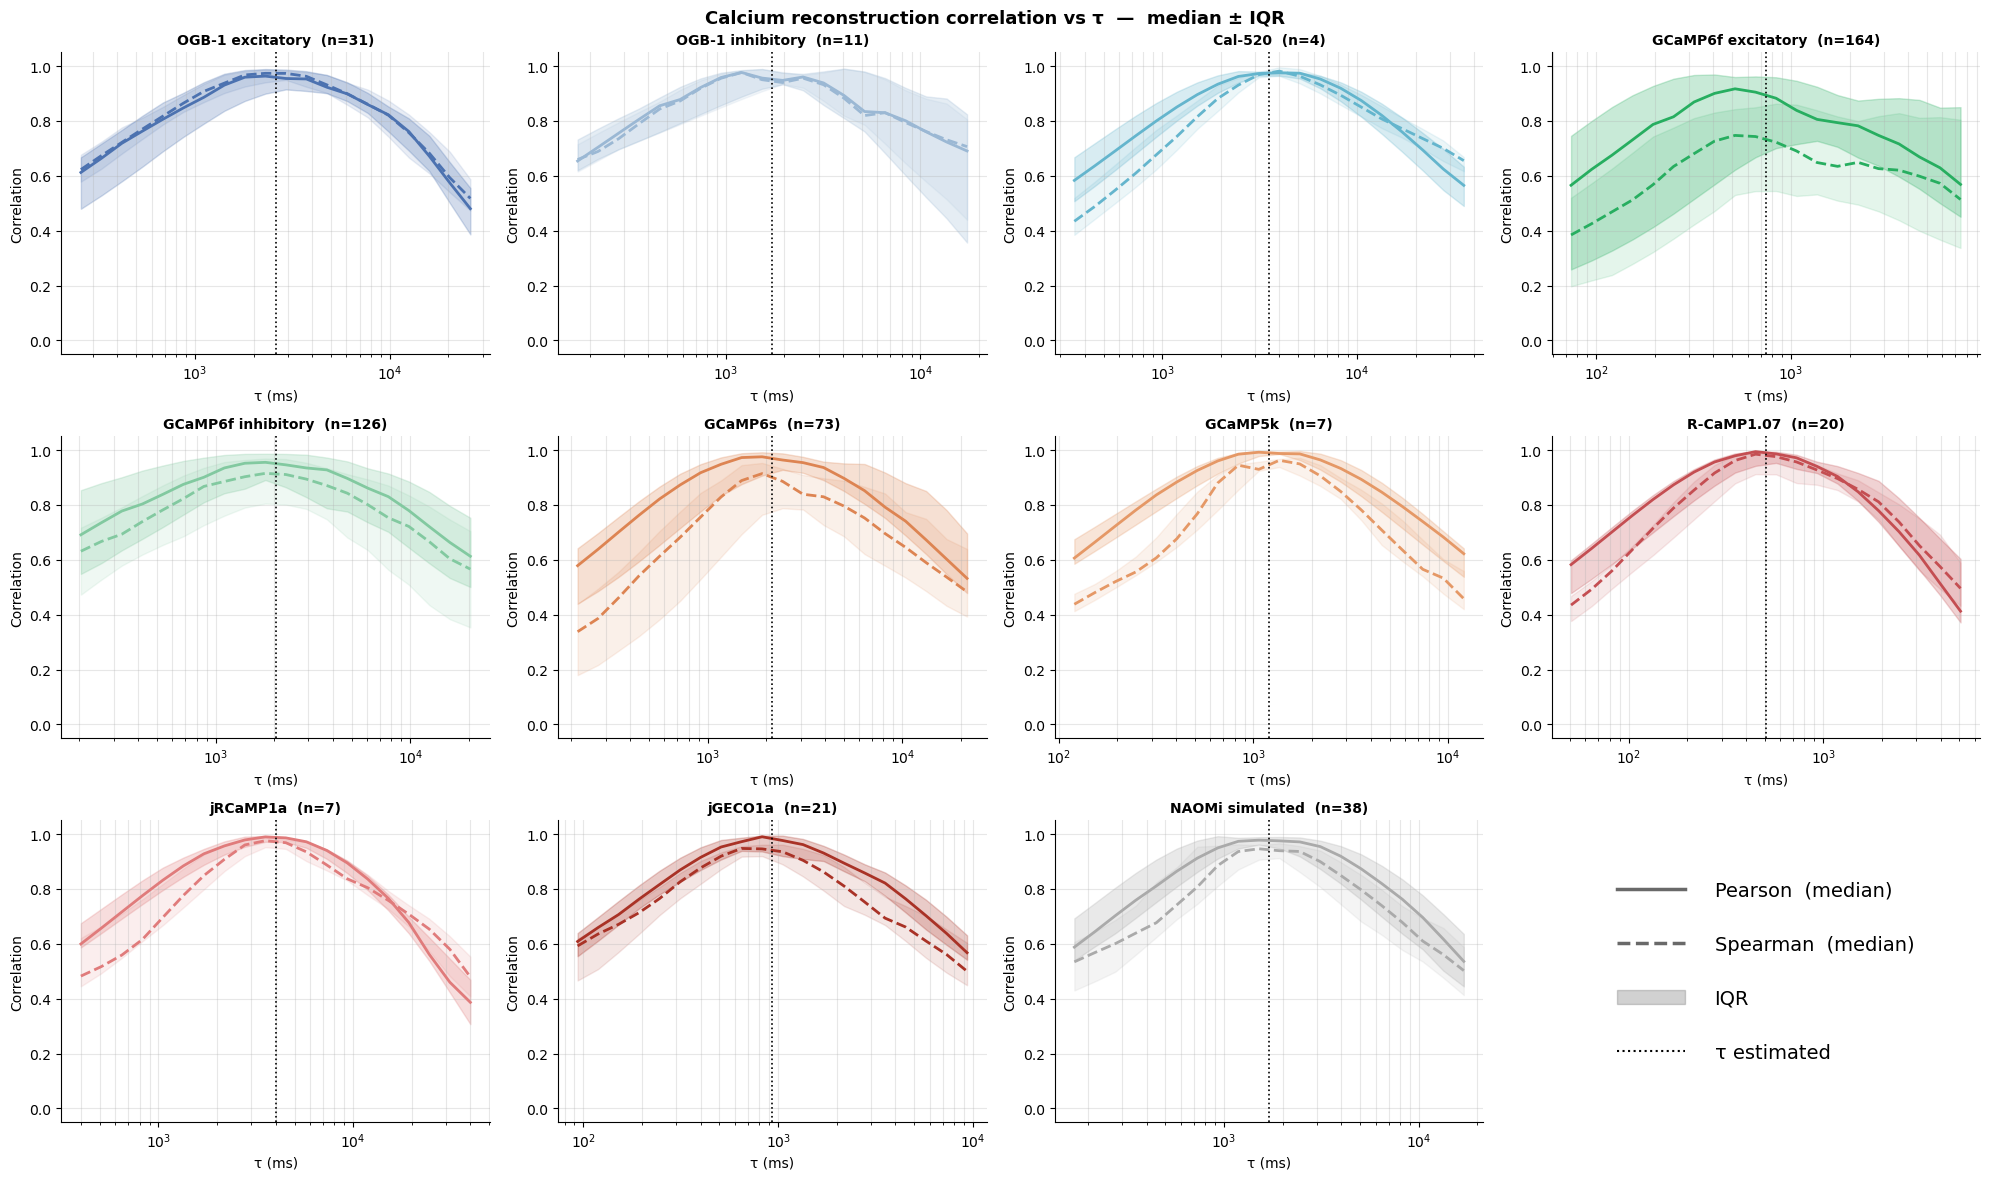

In [63]:
# ── Computation: calcium — ±1 decade ─────────────────────────────────────────
group_indices_v2  = build_group_indices(neurons, DS_TO_GROUP_BY_INDICATOR)
group_results_cal = {}

for grp in tqdm(GROUPS_ORDER_BY_INDICATOR, desc="Calcium sweep"):
    indices = group_indices_v2[grp]
    if not indices: continue

    tau_ms_vals = [t for i in indices
                   for t in [neurons[i].get('tau_ms')]
                   if t is not None and np.isfinite(t) and t > 0]
    if not tau_ms_vals: continue

    median_tau_ms = np.median(tau_ms_vals)
    tau_sweep_ms  = np.logspace(np.log10(median_tau_ms / 10),
                                np.log10(median_tau_ms * 10), 20)
    n_tau, n_neu  = len(tau_sweep_ms), len(indices)
    p_cal = np.full((n_neu, n_tau), np.nan)
    s_cal = np.full((n_neu, n_tau), np.nan)

    for row, ni in enumerate(indices):
        nd       = neurons[ni]
        original = nd.get('upsampled_signal')
        rec_spk  = nd.get('reconstructed_spikes')
        time_vec = nd.get('evenly_spaced_time')
        if original is None or rec_spk is None or time_vec is None: continue
        fs = 1.0 / (time_vec[1] - time_vec[0]) if len(time_vec) > 1 else 100.0

        for col, tm in enumerate(tau_sweep_ms):
            tf = tm * fs / 1000.0
            try:
                sim = simulate_calcium_from_reconstructed_spikes(rec_spk, tau_frames=tf)
                p_cal[row, col] = safe_pearson(original, sim)
                s_cal[row, col] = safe_spearman(original, sim)
            except Exception:
                pass

    group_results_cal[grp] = {
        'tau_sweep_ms': tau_sweep_ms, 'median_tau_ms': median_tau_ms,
        'p_cal': p_cal, 's_cal': s_cal, 'n_neurons': n_neu,
    }

# ── Plot ──────────────────────────────────────────────────────────────────────
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

ncols, nrows = 4, 3
fig, axes   = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat   = axes.flatten()

for ax_i, grp in enumerate(GROUPS_ORDER_BY_INDICATOR):
    ax  = axes_flat[ax_i]
    res = group_results_cal.get(grp)
    if res is None:
        ax.set_visible(False); continue

    color  = GROUP_COLORS_BY_INDICATOR[grp]
    tau_ms = res['tau_sweep_ms']
    p_med  = np.nanmedian(res['p_cal'], axis=0)
    s_med  = np.nanmedian(res['s_cal'], axis=0)
    p_q25  = np.nanpercentile(res['p_cal'], 25, axis=0)
    p_q75  = np.nanpercentile(res['p_cal'], 75, axis=0)
    s_q25  = np.nanpercentile(res['s_cal'], 25, axis=0)
    s_q75  = np.nanpercentile(res['s_cal'], 75, axis=0)

    ax.fill_between(tau_ms, p_q25, p_q75, alpha=0.25, color=color)
    ax.fill_between(tau_ms, s_q25, s_q75, alpha=0.12, color=color)
    ax.plot(tau_ms, p_med, color=color, linewidth=2)
    ax.plot(tau_ms, s_med, color=color, linewidth=2, linestyle='--')
    ax.axvline(res['median_tau_ms'], color='black', linewidth=1.2, linestyle=':')

    ax.set_xscale('log')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('τ (ms)', fontsize=10)
    ax.set_ylabel('Correlation', fontsize=10)
    ax.set_title(f"{grp}  (n={res['n_neurons']})", fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Legend in last free panel ─────────────────────────────────────────────────
legend_ax = axes_flat[len(GROUPS_ORDER_BY_INDICATOR)]
legend_ax.set_visible(True)
legend_ax.axis('off')
handles = [
    mlines.Line2D([], [], color='dimgray', linewidth=2.5, label='Pearson  (median)'),
    mlines.Line2D([], [], color='dimgray', linewidth=2.5, linestyle='--',
                  label='Spearman  (median)'),
    mpatches.Patch(color='dimgray', alpha=0.3, label='IQR'),
    mlines.Line2D([], [], color='black', linewidth=1.5, linestyle=':', label='τ estimated'),
]
legend_ax.legend(handles=handles, loc='center', fontsize=14, frameon=False,
                 handlelength=3.5, handletextpad=1.5, labelspacing=1.8)

for ax_i in range(len(GROUPS_ORDER_BY_INDICATOR) + 1, len(axes_flat)):
    axes_flat[ax_i].set_visible(False)

plt.suptitle(
    'Calcium reconstruction correlation vs τ  —  median ± IQR',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


Binned rate sweep: 100%|██████████| 11/11 [01:20<00:00,  7.32s/it]


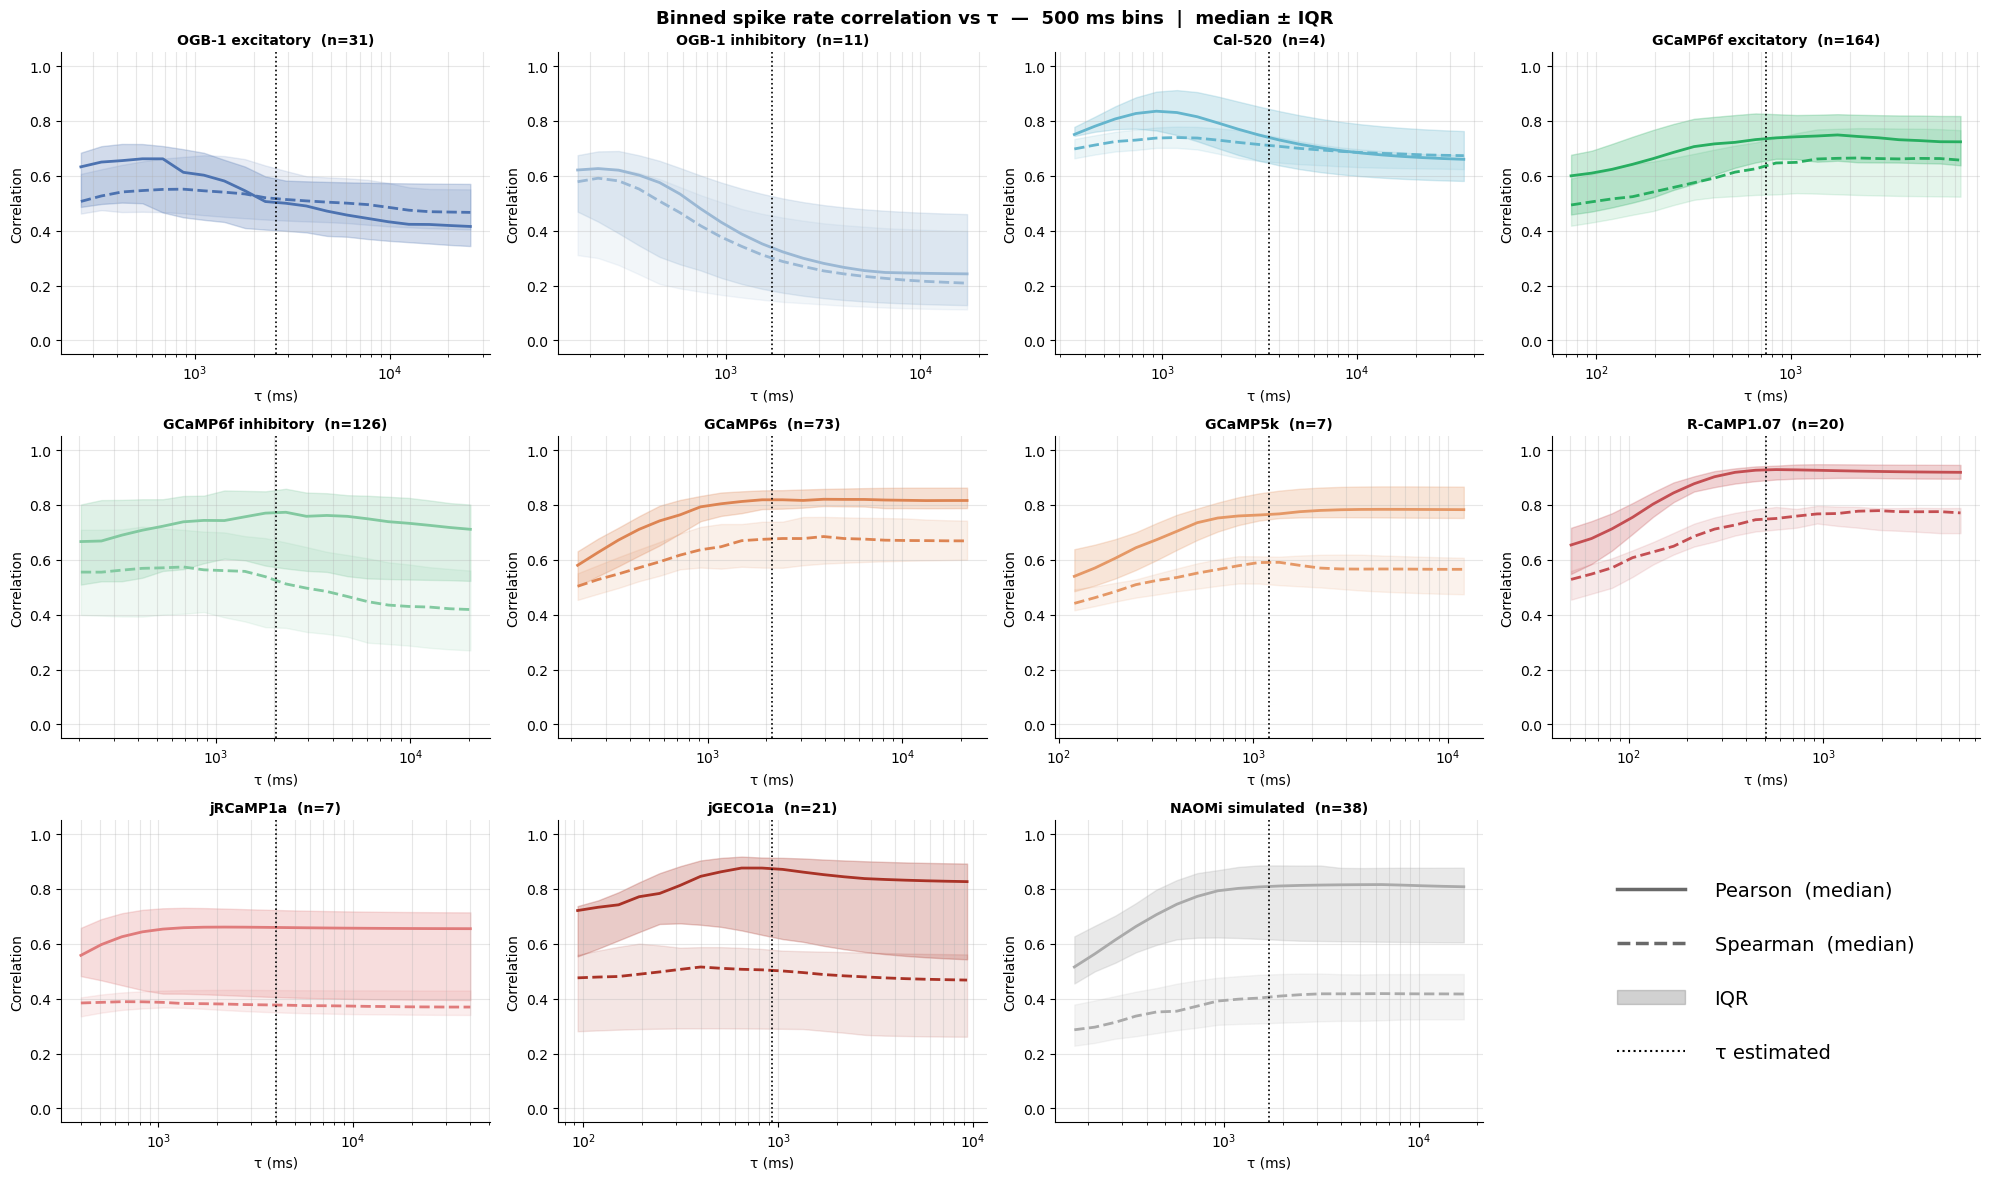

In [64]:
# ── Computation: binned spike rate — ±1 decade, BIN_MS=500 ───────────────────
BIN_MS = 500.0  # ms — chosen from 2D sweep in active_neurons.ipynb

group_indices_v2     = build_group_indices(neurons, DS_TO_GROUP_BY_INDICATOR)
group_results_binned = {}

for grp in tqdm(GROUPS_ORDER_BY_INDICATOR, desc="Binned rate sweep"):
    indices = group_indices_v2[grp]
    if not indices: continue

    tau_ms_vals = [t for i in indices
                   for t in [neurons[i].get('tau_ms')]
                   if t is not None and np.isfinite(t) and t > 0]
    if not tau_ms_vals: continue

    median_tau_ms = np.median(tau_ms_vals)
    tau_sweep_ms  = np.logspace(np.log10(median_tau_ms / 10),
                                np.log10(median_tau_ms * 10), 20)
    n_tau, n_neu  = len(tau_sweep_ms), len(indices)
    p_bin = np.full((n_neu, n_tau), np.nan)
    s_bin = np.full((n_neu, n_tau), np.nan)

    for row, ni in enumerate(indices):
        nd       = neurons[ni]
        original = nd.get('upsampled_signal')
        time_vec = nd.get('evenly_spaced_time')
        if original is None or time_vec is None: continue

        T  = len(time_vec)
        fs = 1.0 / (time_vec[1] - time_vec[0]) if T > 1 else 100.0
        bin_frames = max(1, int(round(BIN_MS * fs / 1000.0)))
        n_bins = T // bin_frames
        if n_bins < 3: continue
        sl = n_bins * bin_frames

        true_train  = get_spikes_train(nd['original_neuron']['spikes'], time_vec).astype(float)
        true_binned = true_train[:sl].reshape(n_bins, bin_frames).sum(axis=1)

        for col, tm in enumerate(tau_sweep_ms):
            tf = tm * fs / 1000.0
            try:
                rec        = np.clip(reconstruct_spikes(original, tau=tf), 0, None)
                rec_binned = rec[:sl].reshape(n_bins, bin_frames).sum(axis=1)
                p_bin[row, col] = safe_pearson(true_binned, rec_binned)
                s_bin[row, col] = safe_spearman(true_binned, rec_binned)
            except Exception:
                pass

    group_results_binned[grp] = {
        'tau_sweep_ms': tau_sweep_ms, 'median_tau_ms': median_tau_ms,
        'p_bin': p_bin, 's_bin': s_bin, 'n_neurons': n_neu,
    }

# ── Plot ──────────────────────────────────────────────────────────────────────
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

ncols, nrows = 4, 3
fig, axes   = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat   = axes.flatten()

for ax_i, grp in enumerate(GROUPS_ORDER_BY_INDICATOR):
    ax  = axes_flat[ax_i]
    res = group_results_binned.get(grp)
    if res is None:
        ax.set_visible(False); continue

    color  = GROUP_COLORS_BY_INDICATOR[grp]
    tau_ms = res['tau_sweep_ms']
    p_med  = np.nanmedian(res['p_bin'], axis=0)
    s_med  = np.nanmedian(res['s_bin'], axis=0)
    p_q25  = np.nanpercentile(res['p_bin'], 25, axis=0)
    p_q75  = np.nanpercentile(res['p_bin'], 75, axis=0)
    s_q25  = np.nanpercentile(res['s_bin'], 25, axis=0)
    s_q75  = np.nanpercentile(res['s_bin'], 75, axis=0)

    ax.fill_between(tau_ms, p_q25, p_q75, alpha=0.25, color=color)
    ax.fill_between(tau_ms, s_q25, s_q75, alpha=0.12, color=color)
    ax.plot(tau_ms, p_med, color=color, linewidth=2)
    ax.plot(tau_ms, s_med, color=color, linewidth=2, linestyle='--')
    ax.axvline(res['median_tau_ms'], color='black', linewidth=1.2, linestyle=':')

    ax.set_xscale('log')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('τ (ms)', fontsize=10)
    ax.set_ylabel('Correlation', fontsize=10)
    ax.set_title(f"{grp}  (n={res['n_neurons']})", fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_ax = axes_flat[len(GROUPS_ORDER_BY_INDICATOR)]
legend_ax.set_visible(True)
legend_ax.axis('off')
handles = [
    mlines.Line2D([], [], color='dimgray', linewidth=2.5, label='Pearson  (median)'),
    mlines.Line2D([], [], color='dimgray', linewidth=2.5, linestyle='--',
                  label='Spearman  (median)'),
    mpatches.Patch(color='dimgray', alpha=0.3, label='IQR'),
    mlines.Line2D([], [], color='black', linewidth=1.5, linestyle=':', label='τ estimated'),
]
legend_ax.legend(handles=handles, loc='center', fontsize=14, frameon=False,
                 handlelength=3.5, handletextpad=1.5, labelspacing=1.8)

for ax_i in range(len(GROUPS_ORDER_BY_INDICATOR) + 1, len(axes_flat)):
    axes_flat[ax_i].set_visible(False)

plt.suptitle(
    f'Binned spike rate correlation vs τ  —  {BIN_MS:.0f} ms bins  |  median ± IQR',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


Heatmap sweep: 100%|██████████| 11/11 [11:28<00:00, 62.61s/it]
/tmp/ipykernel_551457/3072392479.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


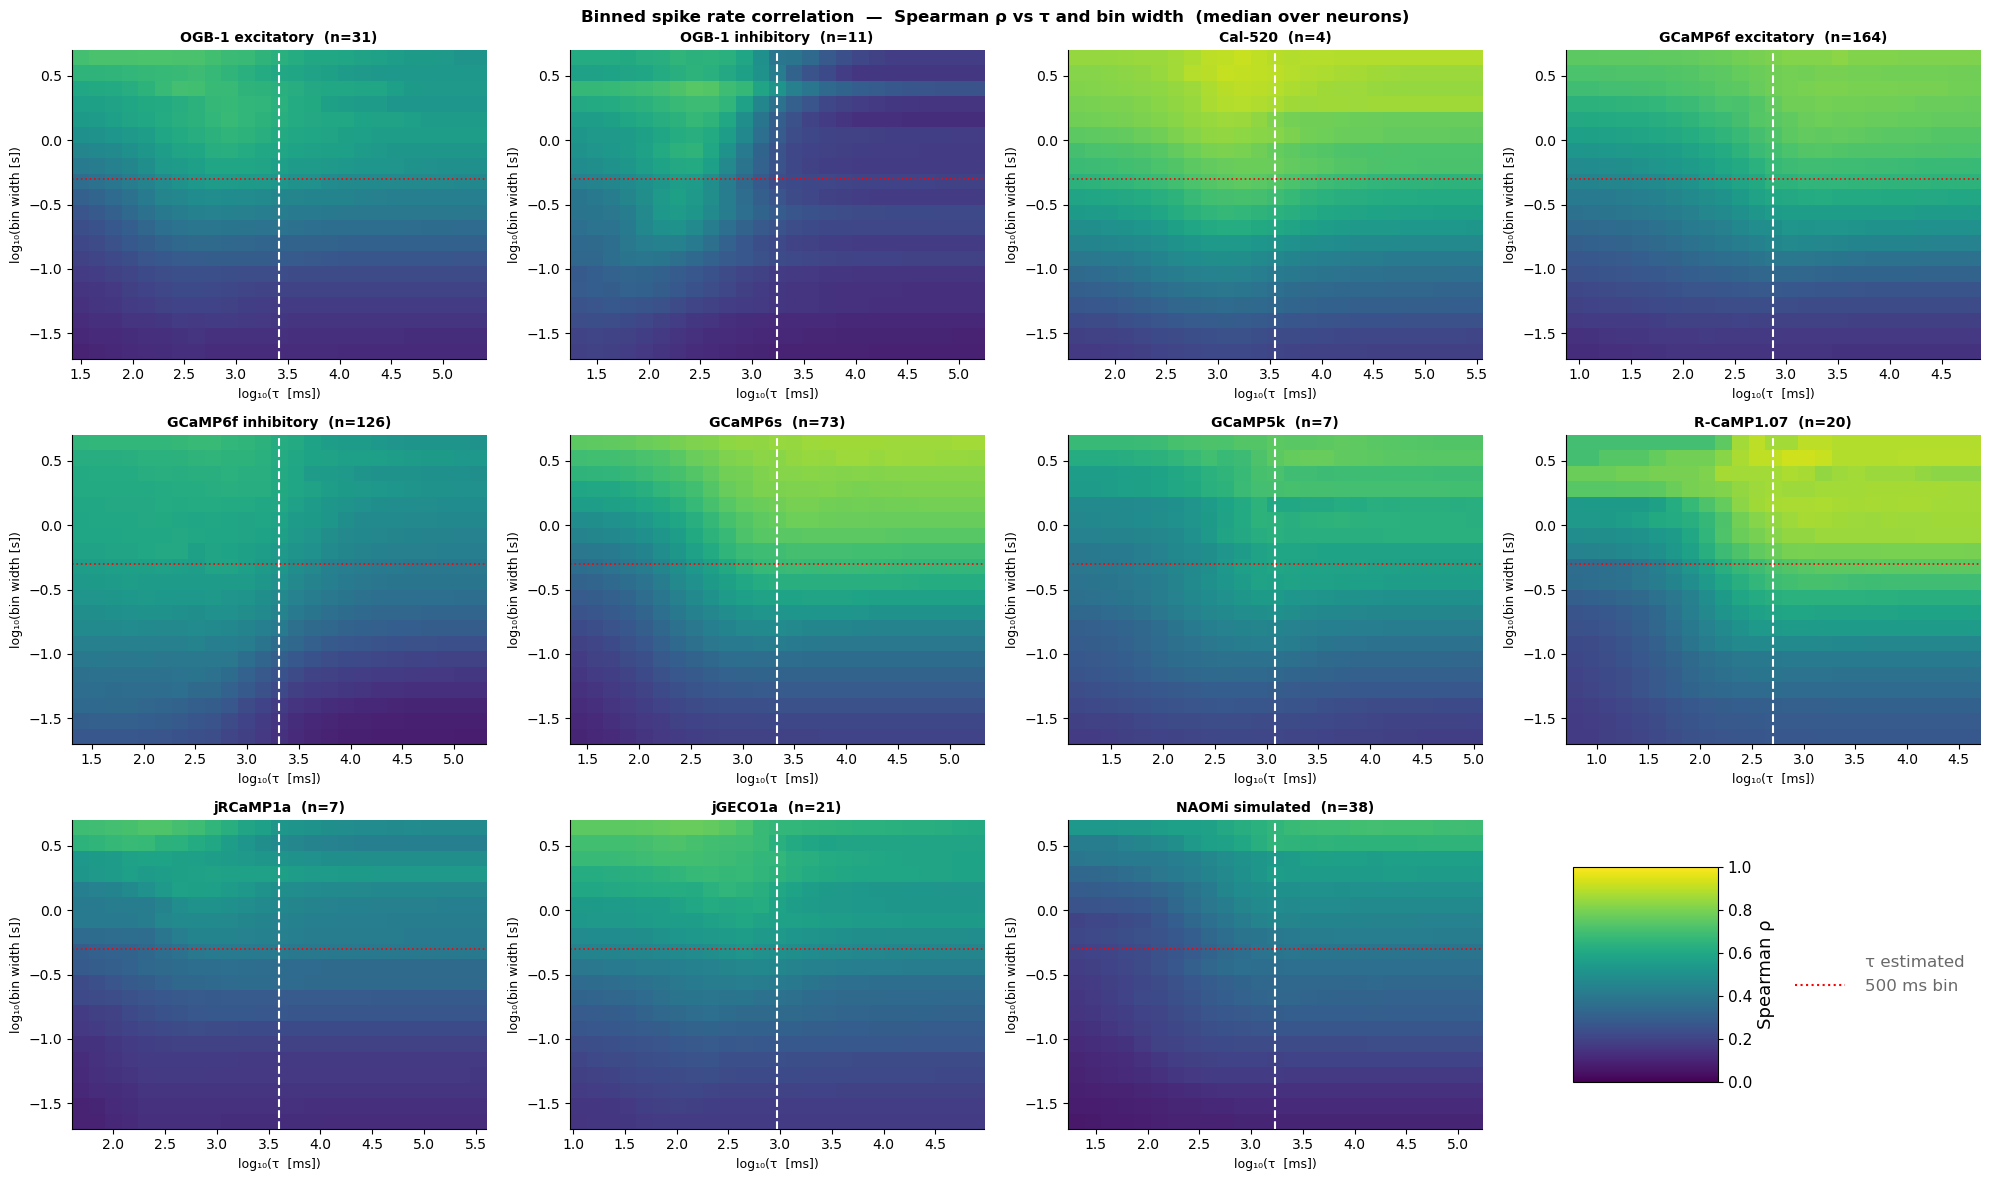

In [65]:
# ── Computation: binned rate — τ × bin_width heatmap ─────────────────────────
bin_widths_s  = np.logspace(np.log10(0.02), np.log10(5.0), 20)   # 20 ms → 5 s

group_indices_v2      = build_group_indices(neurons, DS_TO_GROUP_BY_INDICATOR)
group_results_heatmap = {}

for grp in tqdm(GROUPS_ORDER_BY_INDICATOR, desc="Heatmap sweep"):
    indices = group_indices_v2[grp]
    if not indices: continue

    tau_ms_vals = [t for i in indices
                   for t in [neurons[i].get('tau_ms')]
                   if t is not None and np.isfinite(t) and t > 0]
    if not tau_ms_vals: continue

    median_tau_ms = np.median(tau_ms_vals)
    tau_sweep_ms  = np.logspace(np.log10(median_tau_ms / 100),
                                np.log10(median_tau_ms * 100), 25)

    n_tau, n_bw, n_neu = len(tau_sweep_ms), len(bin_widths_s), len(indices)
    corr_mat = np.full((n_neu, n_tau, n_bw), np.nan)

    for row, ni in enumerate(indices):
        nd       = neurons[ni]
        original = nd.get('upsampled_signal')
        time_vec = nd.get('evenly_spaced_time')
        if original is None or time_vec is None: continue

        T  = len(time_vec)
        fs = 1.0 / (time_vec[1] - time_vec[0]) if T > 1 else 100.0
        true_train = get_spikes_train(nd['original_neuron']['spikes'], time_vec).astype(float)

        for col, tm in enumerate(tau_sweep_ms):
            tf = tm * fs / 1000.0
            try:
                rec = np.clip(reconstruct_spikes(original, tau=tf), 0, None)
            except Exception:
                continue

            for bi, bw in enumerate(bin_widths_s):
                bin_frames = max(1, int(round(bw * fs)))
                n_bins     = T // bin_frames
                if n_bins < 3: continue
                sl     = n_bins * bin_frames
                true_b = true_train[:sl].reshape(n_bins, bin_frames).sum(axis=1)
                rec_b  = rec       [:sl].reshape(n_bins, bin_frames).sum(axis=1)
                corr_mat[row, col, bi] = safe_spearman(true_b, rec_b)

    group_results_heatmap[grp] = {
        'tau_sweep_ms' : tau_sweep_ms,
        'median_tau_ms': median_tau_ms,
        'bin_widths_s' : bin_widths_s,
        'corr_mat'     : corr_mat,
        'n_neurons'    : n_neu,
    }

# ── Plot ──────────────────────────────────────────────────────────────────────
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines

ncols, nrows = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat  = axes.flatten()

for ax_i, grp in enumerate(GROUPS_ORDER_BY_INDICATOR):
    ax  = axes_flat[ax_i]
    res = group_results_heatmap.get(grp)
    if res is None:
        ax.set_visible(False); continue

    med    = np.nanmedian(res['corr_mat'], axis=0).T   # (n_bw, n_tau)
    tau_ms = res['tau_sweep_ms']
    bw_s   = res['bin_widths_s']

    ax.imshow(
        med, aspect='auto', origin='lower', vmin=0, vmax=1, cmap='viridis',
        extent=[np.log10(tau_ms[0]), np.log10(tau_ms[-1]),
                np.log10(bw_s[0]),   np.log10(bw_s[-1])]
    )
    ax.axvline(np.log10(res['median_tau_ms']), color='white',
               linestyle='--', linewidth=1.5)
    ax.axhline(np.log10(0.5), color='red', linestyle=':', linewidth=1.2)  # 500 ms reference

    ax.set_xlabel('log₁₀(τ  [ms])', fontsize=9)
    ax.set_ylabel('log₁₀(bin width [s])', fontsize=9)
    ax.set_title(f"{grp}  (n={res['n_neurons']})", fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Colorbar + legend in last free panel ─────────────────────────────────────
legend_ax = axes_flat[len(GROUPS_ORDER_BY_INDICATOR)]
legend_ax.set_visible(True)
legend_ax.axis('off')

cax = inset_axes(legend_ax, width='35%', height='70%', loc='center left')
sm  = ScalarMappable(cmap='viridis', norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Spearman ρ', fontsize=13)
cbar.ax.tick_params(labelsize=11)

legend_ax.legend(
    handles=[
        mlines.Line2D([], [], color='white', linestyle='--', linewidth=2,
                      label='τ estimated', markerfacecolor='dimgray'),
        mlines.Line2D([], [], color='red',   linestyle=':',  linewidth=1.5,
                      label='500 ms bin',   markerfacecolor='dimgray'),
    ],
    loc='center right', fontsize=12, frameon=False,
    handlelength=3, handletextpad=1.2, labelcolor='dimgray'
)

for ax_i in range(len(GROUPS_ORDER_BY_INDICATOR) + 1, len(axes_flat)):
    axes_flat[ax_i].set_visible(False)

plt.suptitle(
    'Binned spike rate correlation  —  Spearman ρ vs τ and bin width  (median over neurons)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()


In [ ]:
fig.savefig('cumsum_and_calcium_with_slope_factor.png', dpi=300)
print("Saved cumsum_and_calcium_with_slope_factor.png")


### 7.8  Single-neuron summary plot

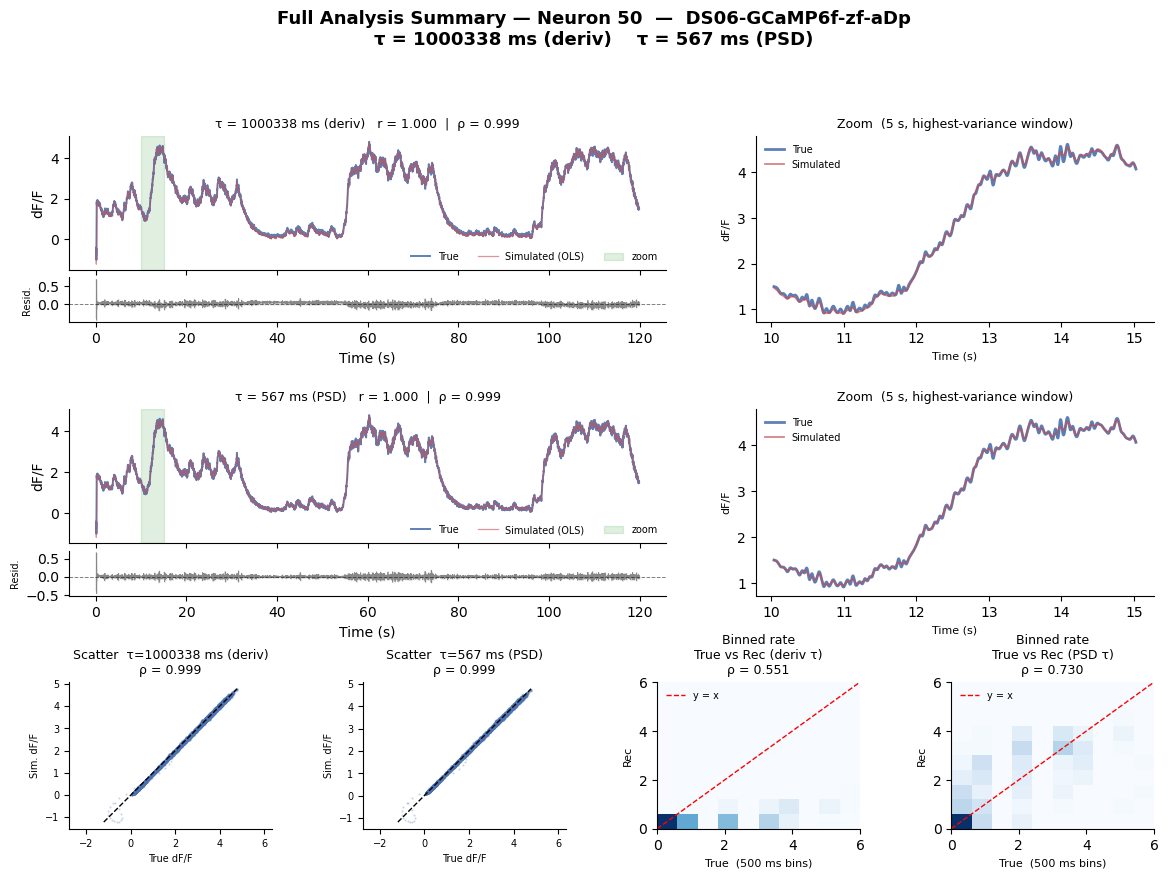

In [79]:
# Change neuron_idx to inspect a different neuron
plot_neuron_summary(50, neurons, df_measurements)
